## Model Training with Class Imbalance Handling (Decision Trees, XGBoost, Random Forests, SMOTE) ##

The dataset has a **~9:1 class imbalance** (90.1% negative, 9.9% positive). Accuracy is misleading here — we optimize **F1-score, recall, precision, ROC-AUC, and PR-AUC** for the minority (cancer) class.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score,
    average_precision_score, make_scorer, accuracy_score, balanced_accuracy_score,
)
from sklearn.utils import resample

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

**Loading Dataset**

In [2]:
df = pd.read_csv("../Dataset/cleaned_gcs_kushal.csv")

# Convert boolean one-hot columns to integers for sklearn / xgboost
for col in df.select_dtypes(include="bool").columns:
    df[col] = df[col].astype(int)

df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown,mature_mirna_id_MIR123_1,mature_mirna_id_MIR234_2,mature_mirna_id_MIR345_3,target_symbol_CDH1,target_symbol_KRAS,target_symbol_TP53
0,43,1,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
1,86,0,1,0,0,1,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
2,68,1,0,1,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
3,57,0,0,0,0,1,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
4,33,1,0,1,1,0,1,1,0,0,...,0,0,1,0,1,0,0,1,0,0


### Features and Target ###

In [3]:
X = df.drop("label", axis=1)
y = df["label"]

### Class Imbalance Overview ###

Class distribution:
label
0    191395
1     20959
Name: count, dtype: int64

Imbalance ratio (majority:minority): 9.1:1
Minority class prevalence: 9.9%


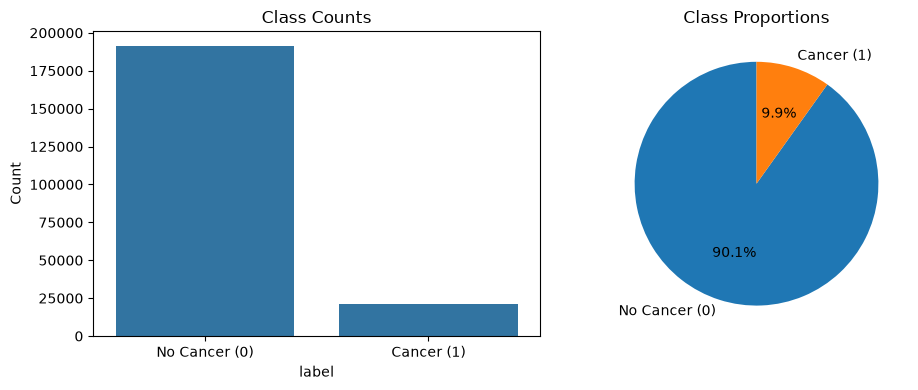

In [4]:
class_counts = y.value_counts().sort_index()
imbalance_ratio = class_counts[0] / class_counts[1]

print("Class distribution:")
print(class_counts)
print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.1f}:1")
print(f"Minority class prevalence: {100 * class_counts[1] / len(y):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=class_counts.index.map({0: "No Cancer (0)", 1: "Cancer (1)"}), y=class_counts.values, ax=axes[0])
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")

axes[1].pie(class_counts, labels=["No Cancer (0)", "Cancer (1)"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

### Feature Exploration & Visualizations ###

Understanding how **clinical**, **diagnostic**, **miRNA target-prediction**, and **encoded categorical** features relate to the cancer label guides model design. The plots below summarize distributions, correlations, and cancer prevalence by feature group.

In [ ]:
# --- Feature group definitions ---
CLINICAL_FEATURES = [
    "age", "gender", "family_history", "smoking_habits", "alcohol_consumption",
    "helicobacter_pylori_infection", "dietary_habits",
]
DIAGNOSTIC_FEATURES = ["endoscopic_images", "biopsy_results", "ct_scan"]
MIRNA_SCORE_FEATURES = [
    "diana_microt", "elmmo", "microcosm", "miranda", "mirdb", "pictar", "pita", "targetscan",
    "predicted.sum", "all.sum",
]
ENCODED_FEATURES = [
    c for c in X.columns
    if c not in CLINICAL_FEATURES + DIAGNOSTIC_FEATURES + MIRNA_SCORE_FEATURES
]

feature_groups = {
    "Clinical": CLINICAL_FEATURES,
    "Diagnostic": DIAGNOSTIC_FEATURES,
    "miRNA scores": MIRNA_SCORE_FEATURES,
    "Encoded (one-hot)": ENCODED_FEATURES,
}

# Correlation with label (absolute Pearson)
label_corr = (
    df.drop(columns=["label"])
    .corrwith(df["label"])
    .dropna()
    .abs()
    .sort_values(ascending=False)
)

print("Feature groups:")
for group, cols in feature_groups.items():
    print(f"  {group}: {len(cols)} features")
print(f"\nTop 5 |correlation| with label:")
print(label_corr.head().to_string())
print(f"\nNote: max |correlation| ≈ {label_corr.max():.4f} — features have very weak linear signal.")

sns.set_theme(style="whitegrid", context="notebook")

# --- 1. Top features correlated with label ---
fig, ax = plt.subplots(figsize=(8, 6))
top_corr = label_corr.head(15).sort_values()
colors = ["#e74c3c" if f in MIRNA_SCORE_FEATURES else "#3498db" if f in CLINICAL_FEATURES
          else "#2ecc71" if f in DIAGNOSTIC_FEATURES else "#95a5a6" for f in top_corr.index]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_xlabel("|Pearson correlation| with cancer label")
ax.set_title("Top 15 Features by Label Correlation")
ax.axvline(label_corr.max(), color="gray", ls="--", lw=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

# --- 2. Correlation heatmap (top clinical + miRNA features) ---
heatmap_features = list(dict.fromkeys(
    CLINICAL_FEATURES + DIAGNOSTIC_FEATURES + list(label_corr.head(8).index)
))
corr_matrix = df[heatmap_features + ["label"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Heatmap (Clinical, Diagnostic & Top miRNA)")
plt.tight_layout()
plt.show()

# --- 3. Cancer prevalence by binary clinical / diagnostic risk factors ---
binary_features = [
    f for f in CLINICAL_FEATURES + DIAGNOSTIC_FEATURES + ENCODED_FEATURES
    if df[f].nunique() <= 2
]
prevalence_rows = []
for feat in binary_features:
    for val in sorted(df[feat].unique()):
        mask = df[feat] == val
        prevalence_rows.append({
            "Feature": feat.replace("_", " ").title(),
            "Value": "Yes" if val == 1 else "No",
            "Cancer rate (%)": 100 * df.loc[mask, "label"].mean(),
            "Count": mask.sum(),
        })
prev_df = pd.DataFrame(prevalence_rows)

fig, ax = plt.subplots(figsize=(12, max(8, 0.45 * len(binary_features))))
sns.barplot(
    data=prev_df, y="Feature", x="Cancer rate (%)", hue="Value",
    palette={"No": "#3498db", "Yes": "#e74c3c"}, ax=ax,
)
ax.axvline(100 * df["label"].mean(), color="black", ls="--", lw=1,
           label=f"Overall rate ({100 * df['label'].mean():.1f}%)")
ax.set_xlabel("Cancer prevalence (%)")
ax.set_title("Cancer Prevalence by Binary Clinical & Diagnostic Features")
ax.legend(title="Feature value", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- 4. Age distribution by cancer status (sample for speed) ---
sample_n = min(20_000, len(df))
age_sample = df.sample(sample_n, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=age_sample, x="age", hue="label", kde=True, stat="density",
    common_norm=False, palette={0: "#3498db", 1: "#e74c3c"},
    hue_order=[0, 1], ax=axes[0], bins=30, alpha=0.5,
)
axes[0].set_title(f"Age Distribution by Label (n={sample_n:,} sample)")
axes[0].set_xlabel("Age")
axes[0].legend(title="Label", labels=["No Cancer", "Cancer"])

sns.boxplot(
    data=df, x="label", y="age", palette={0: "#3498db", 1: "#e74c3c"}, ax=axes[1],
)
axes[1].set_xticklabels(["No Cancer (0)", "Cancer (1)"])
axes[1].set_title("Age by Cancer Status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()

# --- 5. miRNA prediction score distributions by label ---
mirna_plot_cols = [c for c in MIRNA_SCORE_FEATURES if c in df.columns]
mirna_melt = df[mirna_plot_cols + ["label"]].melt(
    id_vars="label", var_name="Score", value_name="Value"
)
mirna_melt["Label"] = mirna_melt["label"].map({0: "No Cancer", 1: "Cancer"})

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=mirna_melt, x="Score", y="Value", hue="Label",
    palette={"No Cancer": "#3498db", "Cancer": "#e74c3c"}, ax=ax, fliersize=1,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_title("miRNA Target-Prediction Score Distributions by Cancer Label")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

# --- 6. miRNA aggregate scores & predicted ratio ---
df_viz = df.copy()
df_viz["mirna_mean"] = df_viz[mirna_plot_cols[:8]].mean(axis=1)
df_viz["predicted_ratio"] = df_viz["predicted.sum"] / (df_viz["all.sum"] + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["predicted.sum", "all.sum", "predicted_ratio"],
    ["Predicted miRNA targets (sum)", "All miRNA targets (sum)", "Predicted / All ratio"],
):
    sns.violinplot(
        data=df_viz.sample(min(15_000, len(df_viz)), random_state=42),
        x="label", y=col, palette={0: "#3498db", 1: "#e74c3c"}, ax=ax, cut=0,
    )
    ax.set_xticklabels(["No Cancer", "Cancer"])
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Aggregate miRNA Features by Cancer Status", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# --- 7. Diagnostic pathway: count of positive tests vs cancer rate ---
df_viz["positive_diagnostics"] = df_viz[DIAGNOSTIC_FEATURES].sum(axis=1)
diag_summary = (
    df_viz.groupby("positive_diagnostics")["label"]
    .agg(["mean", "count"])
    .reset_index()
)
diag_summary.columns = ["Positive tests (0–3)", "Cancer rate", "Patient count"]
diag_summary["Cancer rate (%)"] = 100 * diag_summary["Cancer rate"]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
sns.barplot(
    data=diag_summary, x="Positive tests (0–3)", y="Patient count",
    color="#bdc3c7", ax=ax1, alpha=0.7,
)
sns.lineplot(
    data=diag_summary, x="Positive tests (0–3)", y="Cancer rate (%)",
    color="#e74c3c", marker="o", linewidth=2, ax=ax2,
)
ax1.set_ylabel("Patient count")
ax2.set_ylabel("Cancer rate (%)")
ax1.set_xlabel("Number of positive diagnostic tests")
ax1.set_title("Diagnostic Test Positivity vs Cancer Prevalence")
plt.tight_layout()
plt.show()

### Training, Validation, and Testing Data Split ###

In [5]:
# Hold out 20% for final test; carve 20% of train for validation (threshold tuning)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train class ratio — 0: {(y_train == 0).sum()}, 1: {(y_train == 1).sum()}")

Train: (135906, 29), Val: (33977, 29), Test: (42471, 29)
Train class ratio — 0: 122492, 1: 13414


### 1. Default Decision Tree Classifier (Baseline) ###

In [ ]:
from model.final_model_DT import y_pred
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("=" * 55)
print("FINAL TEST SET METRICS")
print("=" * 55)
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"Precision (cancer): {prec:.4f}")
print(f"Recall (cancer):    {rec:.4f}")
print(f"F1-Score (cancer):  {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC (AP):        {pr_auc:.4f}")
print("=" * 55)

--- Train Classification Report (Default) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    122492
           1       1.00      1.00      1.00     13414

    accuracy                           1.00    135906
   macro avg       1.00      1.00      1.00    135906
weighted avg       1.00      1.00      1.00    135906

--- Test Classification Report (Default) ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     38279
           1       0.10      0.12      0.11      4192

    accuracy                           0.81     42471
   macro avg       0.50      0.50      0.50     42471
weighted avg       0.82      0.81      0.82     42471



### 2c. Final Model Evaluation & Confusion Matrix ###

The top performing model is evaluated on the holdout test set.

Selected strategy: DT + class_weight='balanced'

FINAL TEST SET METRICS
Accuracy:           0.3583
Balanced Accuracy:  0.5009
Precision (cancer): 0.0989
Recall (cancer):    0.6787
F1-Score (cancer):  0.1727
ROC-AUC:            0.5015
PR-AUC (AP):        0.0989

Classification Report:

               precision    recall  f1-score   support

No Cancer (0)       0.90      0.32      0.48     38279
   Cancer (1)       0.10      0.68      0.17      4192

     accuracy                           0.36     42471
    macro avg       0.50      0.50      0.32     42471
 weighted avg       0.82      0.36      0.45     42471

Confusion Matrix (raw counts):
[[12372 25907]
 [ 1347  2845]]


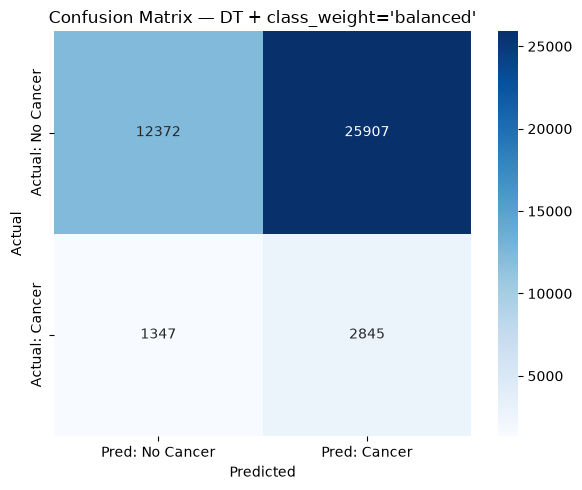

In [8]:
best_strategy = comparison_df.iloc[0]["Strategy"]
best_model = fitted_models[best_strategy]
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

print(f"Selected strategy: {best_strategy}\n")
print("=" * 55)
print("FINAL TEST SET METRICS")
print("=" * 55)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision (cancer): {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Recall (cancer):    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score (cancer):  {f1_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"PR-AUC (AP):        {average_precision_score(y_test, y_prob_final):.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred_final,
    target_names=["No Cancer (0)", "Cancer (1)"],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix (raw counts):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: No Cancer", "Pred: Cancer"],
    yticklabels=["Actual: No Cancer", "Actual: Cancer"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix — {best_strategy}")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

### 2d. Dedicated Evaluation: Decision Tree + Class Weight Balanced + Regularization + SMOTE ###

Explicitly evaluating the combination of SMOTE oversampling with a regularized, class-balanced Decision Tree.

FINAL TEST METRICS: DT + BALANCED + REGULARIZATION + SMOTE
Accuracy:           0.6382
Balanced Accuracy:  0.5067
Precision (cancer): 0.1023
Recall (cancer):    0.3428
F1-Score (cancer):  0.1576
ROC-AUC:            0.5049
PR-AUC (AP):        0.1003

Classification Report:

               precision    recall  f1-score   support

No Cancer (0)       0.90      0.67      0.77     38279
   Cancer (1)       0.10      0.34      0.16      4192

     accuracy                           0.64     42471
    macro avg       0.50      0.51      0.46     42471
 weighted avg       0.82      0.64      0.71     42471

Confusion Matrix (raw counts):
[[25668 12611]
 [ 2755  1437]]


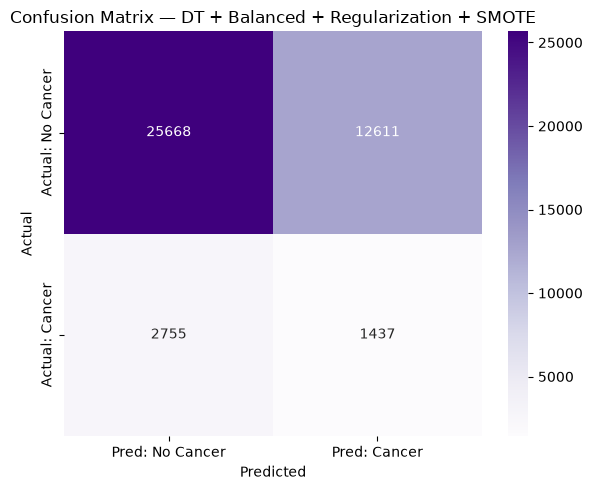

In [9]:
dt_smote_model = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(class_weight="balanced", max_depth=8, min_samples_leaf=50, random_state=42))
])

dt_smote_model.fit(X_train, y_train)
y_pred_dt_smote = dt_smote_model.predict(X_test)
y_prob_dt_smote = dt_smote_model.predict_proba(X_test)[:, 1]

print("=" * 65)
print("FINAL TEST METRICS: DT + BALANCED + REGULARIZATION + SMOTE")
print("=" * 65)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_dt_smote):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, y_pred_dt_smote):.4f}")
print(f"Precision (cancer): {precision_score(y_test, y_pred_dt_smote, zero_division=0):.4f}")
print(f"Recall (cancer):    {recall_score(y_test, y_pred_dt_smote):.4f}")
print(f"F1-Score (cancer):  {f1_score(y_test, y_pred_dt_smote, pos_label=1):.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_prob_dt_smote):.4f}")
print(f"PR-AUC (AP):        {average_precision_score(y_test, y_prob_dt_smote):.4f}")
print("=" * 65)

print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred_dt_smote,
    target_names=["No Cancer (0)", "Cancer (1)"],
    zero_division=0
))

cm_smote = confusion_matrix(y_test, y_pred_dt_smote)
print("Confusion Matrix (raw counts):")
print(cm_smote)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred: No Cancer", "Pred: Cancer"],
    yticklabels=["Actual: No Cancer", "Actual: Cancer"],
    ax=ax,
)
ax.set_title("Confusion Matrix — DT + Balanced + Regularization + SMOTE")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

### 3. Classification Threshold Curves ###

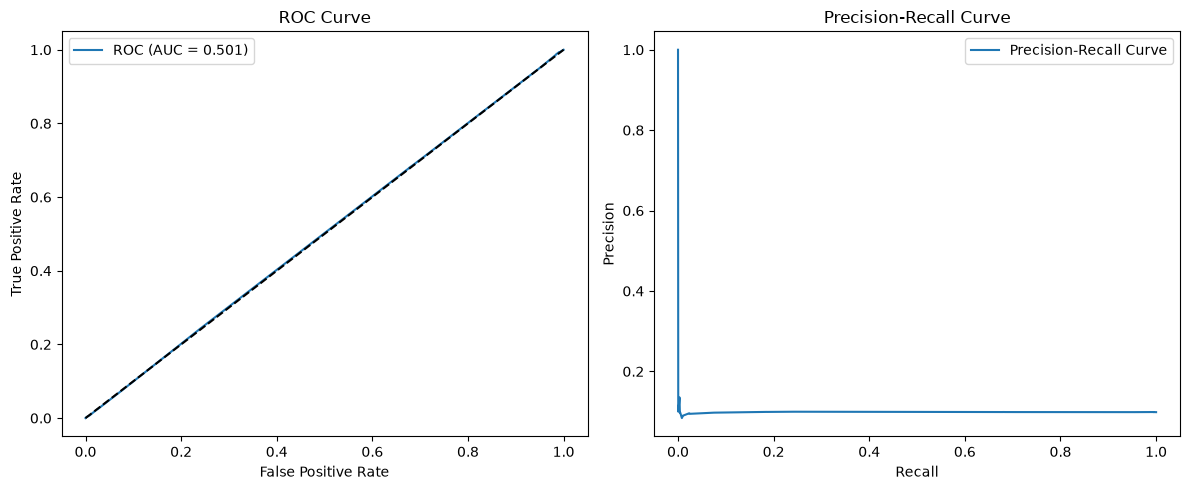

In [10]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

### 5. Feature Importance ###

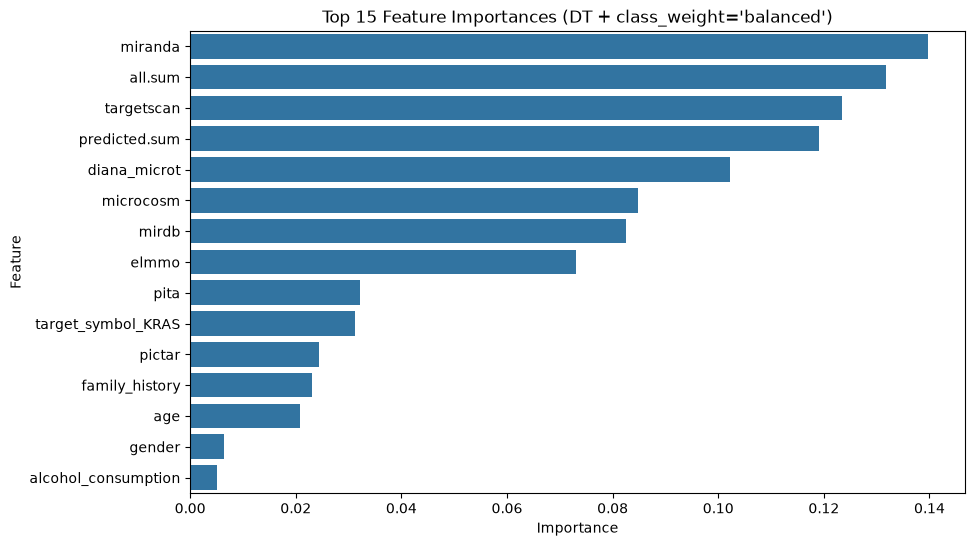

In [12]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["clf"], "feature_importances_"):
    importances = best_model.named_steps["clf"].feature_importances_
else:
    importances = np.zeros(X.shape[1])

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))
plt.title(f"Top 15 Feature Importances ({best_strategy})")
plt.show()